In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

In [2]:
def show(img, title=""):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_pair(a, b, t1="Input", t2="Result"):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(a, cmap="gray")
    ax[0].set_title(t1)
    ax[0].axis("off")

    ax[1].imshow(b, cmap="gray")
    ax[1].set_title(t2)
    ax[1].axis("off")

    plt.show()


In [3]:
img = cv2.imread("rice.png", 0)   # grayscale

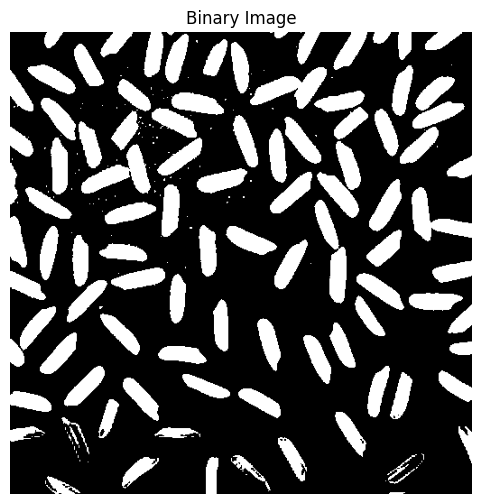

In [4]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

show(binary, "Binary Image")

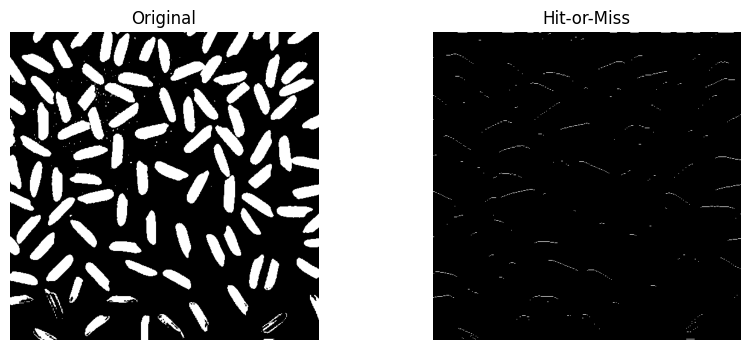

In [5]:
binary01 = (binary // 255).astype(np.uint8)

kernel = np.array([
    [-1, -1, -1],
    [ 0,  1,  0],
    [ 1,  1,  1]
], dtype=np.int8)

hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel)
hitmiss = hitmiss * 255

show_pair(binary, hitmiss, "Original", "Hit-or-Miss")

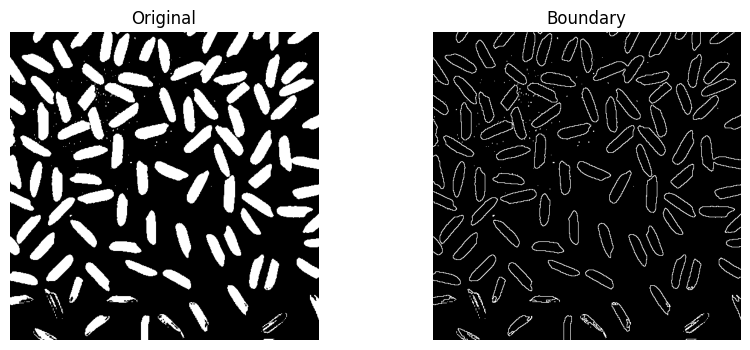

In [6]:
kernel = np.ones((3, 3), np.uint8)

eroded = cv2.erode(binary, kernel)
boundary = cv2.subtract(binary, eroded)

show_pair(binary, boundary, "Original", "Boundary")

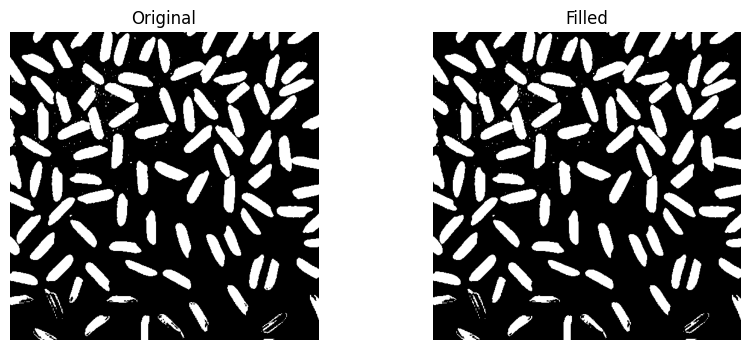

In [7]:
flood = binary.copy()
mask = np.zeros((binary.shape[0]+2, binary.shape[1]+2), np.uint8)

cv2.floodFill(flood, mask, (0, 0), 255)

holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

show_pair(binary, filled, "Original", "Filled")

Number of components: 214


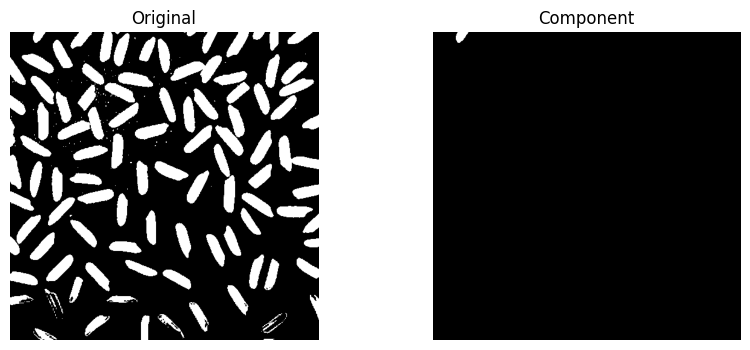

In [8]:
num_labels, labels = cv2.connectedComponents(binary)

print("Number of components:", num_labels)

# взять первый компонент
component = np.zeros_like(binary)
if num_labels > 1:
    component[labels == 1] = 255

show_pair(binary, component, "Original", "Component")